In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as sc

# Hypothesis testing in python

>A hypothesis is a statement about n unkmown population parameter.

- A hypothesis test is a test of two competing hypotheses:
    1. Null hypothesis $(H_0)$ is an existing idea
    2. Alternative hypothesis $(H_A)$ is the new 'challenger' idea

- Either $(H_0)$ OR $(H_A)$ can be true (not both)

- Initially $(H_0)$ is assumed to be true unless proven false by $(H_A)$

## Hypothesis fundamentals
Loading a salary survey dataset from StackOverflow. All survey participants have a data scientist OR a DS-adjacent role.

>Hypothesis: that mean annual consumption of data scientists is $11000

We'll now implement certain steps to validate this hypothesis.

### Hypothesis

In [2]:
# loading data of salary survey by stackoverflow
stackoverflowdf = pd.read_feather('./datasets/stack_overflow.feather')
stackoverflowdf.head(2)

,respondent,main_branch,hobbyist,age,age_1st_code,age_first_code_cut,comp_freq,comp_total,converted_comp,country,...,survey_length,trans,undergrad_major,webframe_desire_next_year,webframe_worked_with,welcome_change,work_week_hrs,years_code,years_code_pro,age_cat
0,36.0,"I am not primarily a developer, but I write co...",Yes,34.0,30.0,adult,Yearly,60000.0,77556.0,United Kingdom,...,Appropriate in length,No,"Computer science, computer engineering, or sof...",Express;React.js,Express;React.js,Just as welcome now as I felt last year,40.0,4.0,3.0,At least 30
1,47.0,I am a developer by profession,Yes,53.0,10.0,child,Yearly,58000.0,74970.0,United Kingdom,...,Appropriate in length,No,"A natural science (such as biology, chemistry,...",Flask;Spring,Flask;Spring,Just as welcome now as I felt last year,40.0,43.0,28.0,At least 30


In [3]:
mean_comp_sample = stackoverflowdf["converted_comp"].mean()
print(f"Overall mean annual compensation is : {mean_comp_sample}")

Overall mean annual compensation is : 119574.71738168952


>We observe that mean of all compensation is different from our hypothesis. 
>
>Now we'll work to determine how significant is this difference from the true mean.

- We'll be generating several bootstrapped-samples (~5K) & calculate their means. 
- We'll then calculate as well as visualize the mean of thes sampled means to get a sense of where the bootstrapped mean of sampled means lies win comparison to the population mean.  

In [4]:
# Creating a list of bootstrapped-sampled means
means_of_bstp = []

# taking 5K mean of bootstrapped samples
for i in range(5000):
    means_of_bstp.append(
        np.mean(stackoverflowdf.sample(frac=1, replace=True)
                ["converted_comp"]))

print(means_of_bstp)

[np.float64(122555.15568332597), np.float64(120077.3171163202), np.float64(132266.19106590006), np.float64(129600.28881026094), np.float64(114275.7859354268), np.float64(110388.82087571871), np.float64(118387.11941618753), np.float64(106058.45997346308), np.float64(126481.81070322866), np.float64(118510.63555948695), np.float64(118447.32773109243), np.float64(112174.27686864219), np.float64(131992.4427244582), np.float64(124869.37151702786), np.float64(114028.44449358691), np.float64(116953.27244582043), np.float64(114657.59177355152), np.float64(118823.47678018575), np.float64(121323.56346749226), np.float64(116572.78726227333), np.float64(112473.12781954887), np.float64(118099.01503759398), np.float64(116922.39628482972), np.float64(122861.87306501548), np.float64(118950.7381689518), np.float64(118329.45820433437), np.float64(115664.8876603273), np.float64(110107.72534276868), np.float64(113650.29898275099), np.float64(110859.48827952234), np.float64(115710.52321981425), np.float64(1

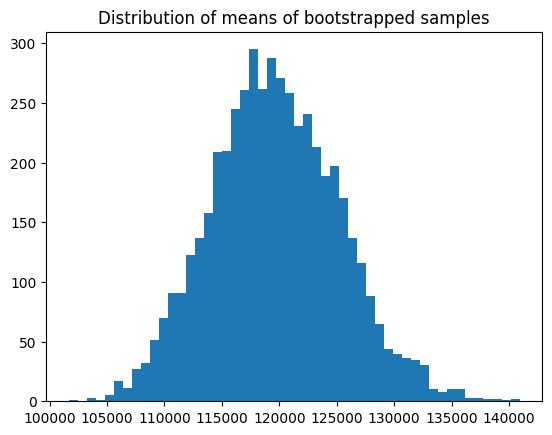

In [5]:
# visualizing the bootstrapped distribution
plt.hist(means_of_bstp, bins=50)
plt.title("Distribution of means of bootstrapped samples")
plt.show()

>The means of the 5K bootstrapped samples appear normally distributed.

>Notice that the mean of the bootstrapped means appears different than the hypothesized value($110K). 

In [7]:
# Calculating standard error
std_err = np.std(means_of_bstp, ddof=1)
std_err

np.float64(5590.390696881082)

### z-scores
>The z-score is a standardized measure that tells us how many standard deviations away from the mean a particular data point lies.

Before testing our hypothesis, we'll be standarding the values using z-scores.

Using a slightliy modified version of the z-score:
$z = \frac{\text{Sample stat} - \text{Hypothsized param value}}{\text{Standard error}}$

Note: that standard error $(SE = \frac{\sigma}{\sqrt{n}})$ quantifies the precision of a sample statistic (usually the mean) in representing the true population parameter.

In [17]:
# using variables to fit into above formula
print(f"The actual mean of population is = {np.round(mean_comp_sample,2)}\n")

print(f"Standard error (precision of sample mean) = {np.round(std_err,2)}\n")

# the hypothsized value being tested
hyp_mean_comp = 110000
print(f"Hypothesized compensation mean = {np.round(hyp_mean_comp,2)}\n")

# calculatng z-score
z_score = (mean_comp_sample - hyp_mean_comp) / std_err
print(f"Calculated z-score = {np.round(z_score,2)}")

The actual mean of population is = 119574.72

Standard error (precision of sample mean) = 5590.39

Hypothesized compensation mean = 110000

Calculated z-score = 1.71


>Thus ,we'll be working to understand whether the z-score (~1.71) is a high or low number
>
>i.e. Whether the sample statistic (mean) is close or far away from the hypothesized value.

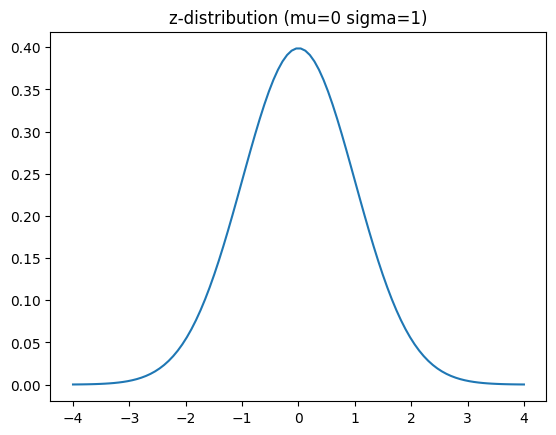

In [22]:
from scipy.stats import norm
mu=0
sigma=1
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 100)
y = norm.pdf(x, mu, sigma)
plt.title("z-distribution (mu=0 sigma=1)")
plt.plot(x,y)
plt.show()

### p-values
In the `stackoverflow` dataset, `age_first_code_cut` classifies when the user first started programming.

Previous research: 35% of software devs started programming as children

This raises a question that can be answered using our current dataset -<br>
*Does the sample provide evidence that a greater proportion of data scientists started programming as children?*

A hypothesis test is a test of two competing hypotheses -- the Null hypothesis $(H_0)$ i.e. an existing idea and an Alternative hypothesis $(H_A)$ is the new 'challenger' idea.

In our scenario: <br>
- $(H_0)$ : proportion of data scientists who started programming as children is 35%
- $(H_A)$ : proportion of data scientists who started programming as children is **greater than 35%**

In [25]:
stackoverflowdf["age_first_code_cut"].value_counts(normalize=True)

age_first_code_cut
adult    0.60858
child    0.39142
Name: proportion, dtype: float64

_____
## Two-sample & ANOVA tests
### Performing t-tests